# Pandas session 1 recap

In [394]:
import pandas as pd

data = pd.DataFrame({
    'A': [1,2,3],
    'B': [4,5,6],
    'C' : [7,8,9]
})

print(data)
print(type(data))

   A  B  C
0  1  4  7
1  2  5  8
2  3  6  9
<class 'pandas.core.frame.DataFrame'>


In [395]:
print(data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3 entries, 0 to 2
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   A       3 non-null      int64
 1   B       3 non-null      int64
 2   C       3 non-null      int64
dtypes: int64(3)
memory usage: 204.0 bytes
None


In [396]:
print(data.describe())

         A    B    C
count  3.0  3.0  3.0
mean   2.0  5.0  8.0
std    1.0  1.0  1.0
min    1.0  4.0  7.0
25%    1.5  4.5  7.5
50%    2.0  5.0  8.0
75%    2.5  5.5  8.5
max    3.0  6.0  9.0


In [397]:
# Slicing/Accessing data

print(data['A']) # 'column' to print column A 
print(data.iloc[1]) # 'row with specific index'  to access index (iloc=index locattion) 'this is series data type'
print(data.iloc[1,2]) # 'single value'
print(data['B'][1])
print(type(data.iloc[1])) # will print series 

0    1
1    2
2    3
Name: A, dtype: int64
A    2
B    5
C    8
Name: 1, dtype: int64
8
5
<class 'pandas.core.series.Series'>


In [398]:

# Change index
data.index = ['x', 'y', 'z']
print(data)

   A  B  C
x  1  4  7
y  2  5  8
z  3  6  9


In [399]:

data_indexed = data.set_index('A', drop=True)
# data_indexed.columns.name = 'Columns'
print(data_indexed)

   B  C
A      
1  4  7
2  5  8
3  6  9


In [400]:
# Reshaping the dataframes

# Melt Example
data = pd.DataFrame(
    {
        'Names': ['Alice', 'Bob', 'Charlie'],
        'Cairo': [1, 0, 1],
        'Alex': [0, 1, 0],
        'Age': [25, 30, 35]
    }
)

print("____Data Before Melt____")
print(data)

data_melted = pd.melt(data, id_vars=['Names', 'Age'], var_name='City', value_name='Visited')
print("____Data After Melt____")
print(data_melted)

____Data Before Melt____
     Names  Cairo  Alex  Age
0    Alice      1     0   25
1      Bob      0     1   30
2  Charlie      1     0   35
____Data After Melt____
     Names  Age   City  Visited
0    Alice   25  Cairo        1
1      Bob   30  Cairo        0
2  Charlie   35  Cairo        1
3    Alice   25   Alex        0
4      Bob   30   Alex        1
5  Charlie   35   Alex        0


In [401]:
# Pivot Example
data_pivoted = data_melted.pivot(index=['Names', 'Age'], columns='City', values='Visited')
print("____Data After Pivot____")
print(data_pivoted)

____Data After Pivot____
City         Alex  Cairo
Names   Age             
Alice   25      0      1
Bob     30      1      0
Charlie 35      0      1


In [402]:

# Concatenation and Merging
data1 = pd.DataFrame({
    'ID': [1, 2, 3],
    'Name': ['Alice', 'Bob', 'Charlie']
})
data2 = pd.DataFrame({
    'ID': [4, 5, 6],
    'Name': ['David', 'Eva', 'Frank']
})
data_concat = pd.concat([data1, data2], ignore_index=True)
print("____Concatenated Data____")
print(data_concat)

____Concatenated Data____
   ID     Name
0   1    Alice
1   2      Bob
2   3  Charlie
3   4    David
4   5      Eva
5   6    Frank


In [403]:

# Adding more columns
data_concat['Age'] = [25, 30, 35, 40, 28, 33]
print("____Data After Adding Age Column____")
print(data_concat)

____Data After Adding Age Column____
   ID     Name  Age
0   1    Alice   25
1   2      Bob   30
2   3  Charlie   35
3   4    David   40
4   5      Eva   28
5   6    Frank   33


In [404]:

# Selections based on conditions
adults = data_concat[data_concat['Age'] >= 30]
print("____Adult Data____")
print(adults)

____Adult Data____
   ID     Name  Age
1   2      Bob   30
2   3  Charlie   35
3   4    David   40
5   6    Frank   33


# Session 2


In [405]:
data = pd.read_csv('../data/netflix_movies.csv')
data.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [406]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [407]:
# bt3rfne 3dd el (rows,columns)
data.shape

(8807, 12)

In [408]:
data_sample = data.sample(1000) # byakhod sample(no of rows) 7sb ma te7adelo fl parameter 
data_sample.shape

(1000, 12)

In [409]:
# count unique directors
print(data_sample['director'].nunique())

646


In [410]:
# Group By type
print(data_sample.groupby('type').size())

type
Movie      689
TV Show    311
dtype: int64


In [411]:
# Group By type
print(data_sample.groupby('listed_in').size().sort_values(ascending=False).head(20))

listed_in
Stand-Up Comedy                                         39
Documentaries                                           39
Comedies, Dramas, International Movies                  38
Dramas, International Movies                            35
Kids' TV                                                30
Documentaries, International Movies                     29
Dramas, Independent Movies, International Movies        26
Children & Family Movies, Comedies                      25
Children & Family Movies                                24
Dramas                                                  19
Comedies, International Movies                          19
International TV Shows, TV Dramas                       18
Action & Adventure, Dramas, International Movies        17
Comedies, International Movies, Romantic Movies         17
Dramas, Independent Movies                              16
Action & Adventure, International Movies                16
Dramas, International Movies, Romantic Movies 

In [412]:
# group by (level= )  means group by specific row 

# Preprocessing

# dealing with missing values

In [413]:
data_sample.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1000 entries, 4928 to 5850
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       1000 non-null   object
 1   type          1000 non-null   object
 2   title         1000 non-null   object
 3   director      686 non-null    object
 4   cast          907 non-null    object
 5   country       901 non-null    object
 6   date_added    999 non-null    object
 7   release_year  1000 non-null   int64 
 8   rating        1000 non-null   object
 9   duration      1000 non-null   object
 10  listed_in     1000 non-null   object
 11  description   1000 non-null   object
dtypes: int64(1), object(11)
memory usage: 101.6+ KB


In [414]:
# drop any row with null values using 'dropna()'
data_sample = data_sample.dropna()
data_sample.info()

<class 'pandas.core.frame.DataFrame'>
Index: 590 entries, 4928 to 5754
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       590 non-null    object
 1   type          590 non-null    object
 2   title         590 non-null    object
 3   director      590 non-null    object
 4   cast          590 non-null    object
 5   country       590 non-null    object
 6   date_added    590 non-null    object
 7   release_year  590 non-null    int64 
 8   rating        590 non-null    object
 9   duration      590 non-null    object
 10  listed_in     590 non-null    object
 11  description   590 non-null    object
dtypes: int64(1), object(11)
memory usage: 59.9+ KB


In [415]:
# fill any missing values using 'fillna()'
data_sample['director'].fillna('Unknown', inplace=True)
data_sample.info()

<class 'pandas.core.frame.DataFrame'>
Index: 590 entries, 4928 to 5754
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       590 non-null    object
 1   type          590 non-null    object
 2   title         590 non-null    object
 3   director      590 non-null    object
 4   cast          590 non-null    object
 5   country       590 non-null    object
 6   date_added    590 non-null    object
 7   release_year  590 non-null    int64 
 8   rating        590 non-null    object
 9   duration      590 non-null    object
 10  listed_in     590 non-null    object
 11  description   590 non-null    object
dtypes: int64(1), object(11)
memory usage: 59.9+ KB


C:\Users\fxrxh\AppData\Local\Temp\ipykernel_23496\1590491435.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data_sample['director'].fillna('Unknown', inplace=True)


# Merging

In [416]:
# Merge -> like join in sql, we join on a common PK, which will be 'A' in this example

data = pd.DataFrame({
    'A': [1,2,3],
    'B': [4,5,6],
    'C': [7,8,9]
})

data2 = pd.DataFrame({
    'A': [1,2,3],
    'D': [10,11,12],
    'E' : [13,14,15]
})

data_merged = pd.merge(data, data2, on='A', how='inner')
print(data_merged)

   A  B  C   D   E
0  1  4  7  10  13
1  2  5  8  11  14
2  3  6  9  12  15


# Plotting

In [417]:
import matplotlib.pyplot as plt

data = pd.read_csv('../data/netflix_movies.csv')
data.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


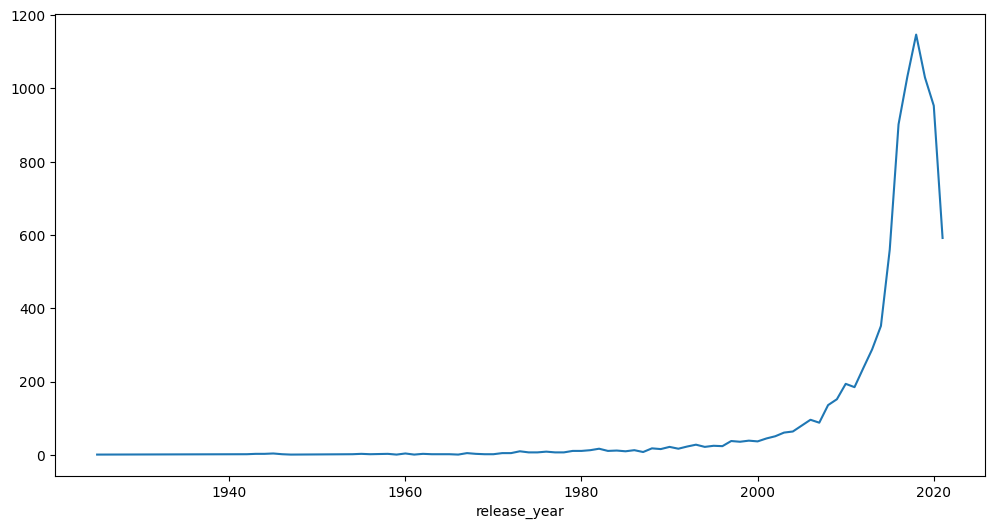

In [418]:

# Group By release_year
movies_per_year =  data.groupby('release_year').size()

movies_per_year.plot(figsize=(12,6))
plt.show()

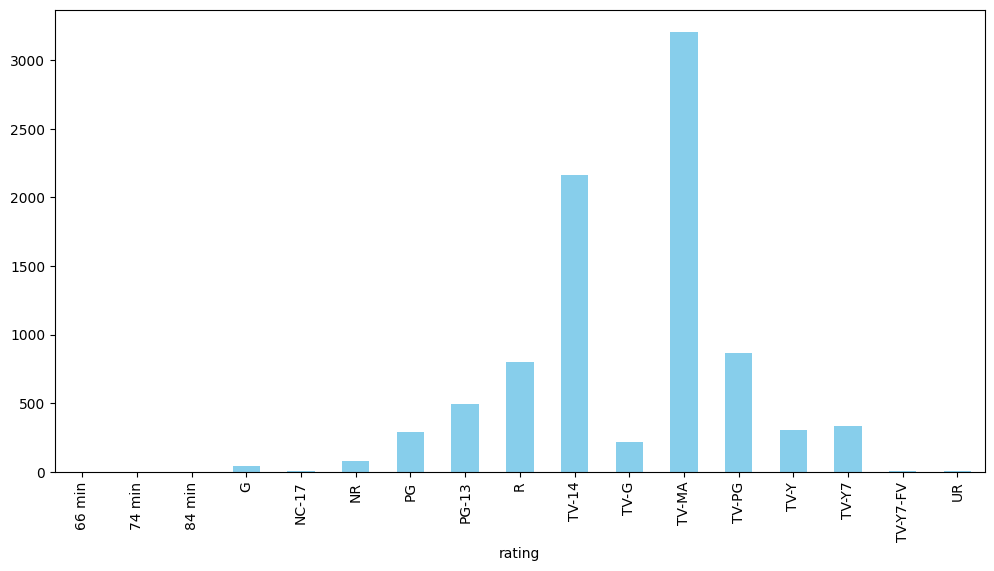

In [419]:
movies_per_rating = data.groupby('rating').size()
movies_per_rating.plot(kind='bar', figsize=(12, 6), color='skyblue')
plt.show()

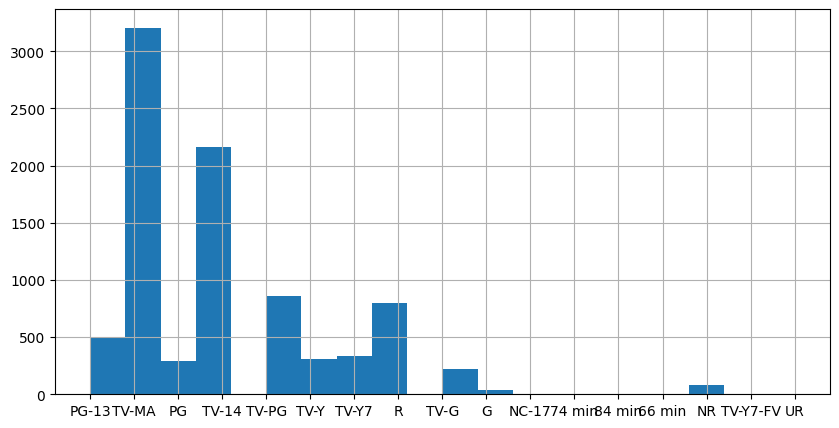

In [420]:
data['rating'].hist(bins=20, figsize=(10, 5))
plt.show()

type          Movie  TV Show
release_year                
1925              0        1
1942              2        0
1943              3        0
1944              3        0
1945              3        1
...             ...      ...
2017            767      265
2018            767      380
2019            633      397
2020            517      436
2021            277      315

[74 rows x 2 columns]


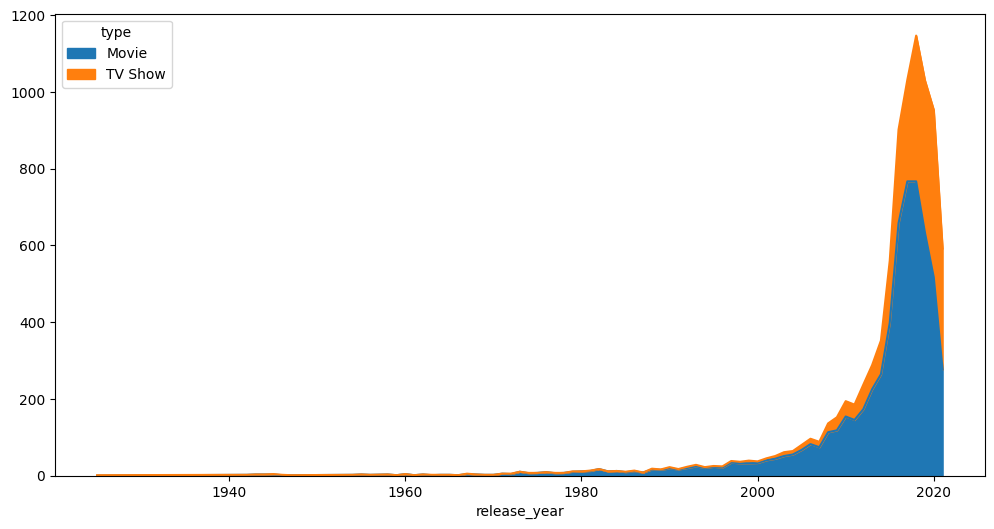

In [421]:
movies_per_type_per_year = data.groupby(['release_year', 'type']).size().unstack(fill_value=0)
print(movies_per_type_per_year)
movies_per_type_per_year.plot(kind='area',figsize=(12, 6))
plt.show()

In [422]:
# note that release_year Dtype is int
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [423]:
# Change the DType 
data['release_year'] = pd.to_datetime(data['release_year'], format='%Y')

In [424]:
# note the release_year  DType changed to date time
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   show_id       8807 non-null   object        
 1   type          8807 non-null   object        
 2   title         8807 non-null   object        
 3   director      6173 non-null   object        
 4   cast          7982 non-null   object        
 5   country       7976 non-null   object        
 6   date_added    8797 non-null   object        
 7   release_year  8807 non-null   datetime64[ns]
 8   rating        8803 non-null   object        
 9   duration      8804 non-null   object        
 10  listed_in     8807 non-null   object        
 11  description   8807 non-null   object        
dtypes: datetime64[ns](1), object(11)
memory usage: 825.8+ KB


In [425]:
data['release_since'] = 2025 - data['release_year'].dt.year

data.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,release_since
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020-01-01,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",5
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021-01-01,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",4
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021-01-01,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,4
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021-01-01,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo...",4
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021-01-01,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...,4


In [426]:
# use apply()  to iterate over all data in column 'listed_in' and split texts

data['spreaded_genres'] = data.apply(lambda row: row['listed_in'].split(', '), axis=1)
print(data['spreaded_genres'].head())

0                                      [Documentaries]
1    [International TV Shows, TV Dramas, TV Mysteries]
2    [Crime TV Shows, International TV Shows, TV Ac...
3                             [Docuseries, Reality TV]
4    [International TV Shows, Romantic TV Shows, TV...
Name: spreaded_genres, dtype: object


In [427]:
# The explode() function creates a new row for each genre in the list, duplicating the rest of the row’s data.
# For example, if a row had ['Drama', 'Comedy'], it becomes two rows: one with 'Drama', one with 'Comedy'.

generes_exploded = data.explode('spreaded_genres')
print(generes_exploded['spreaded_genres'].value_counts())

spreaded_genres
International Movies            2752
Dramas                          2427
Comedies                        1674
International TV Shows          1351
Documentaries                    869
Action & Adventure               859
TV Dramas                        763
Independent Movies               756
Children & Family Movies         641
Romantic Movies                  616
TV Comedies                      581
Thrillers                        577
Crime TV Shows                   470
Kids' TV                         451
Docuseries                       395
Music & Musicals                 375
Romantic TV Shows                370
Horror Movies                    357
Stand-Up Comedy                  343
Reality TV                       255
British TV Shows                 253
Sci-Fi & Fantasy                 243
Sports Movies                    219
Anime Series                     176
Spanish-Language TV Shows        174
TV Action & Adventure            168
Korean TV Shows       

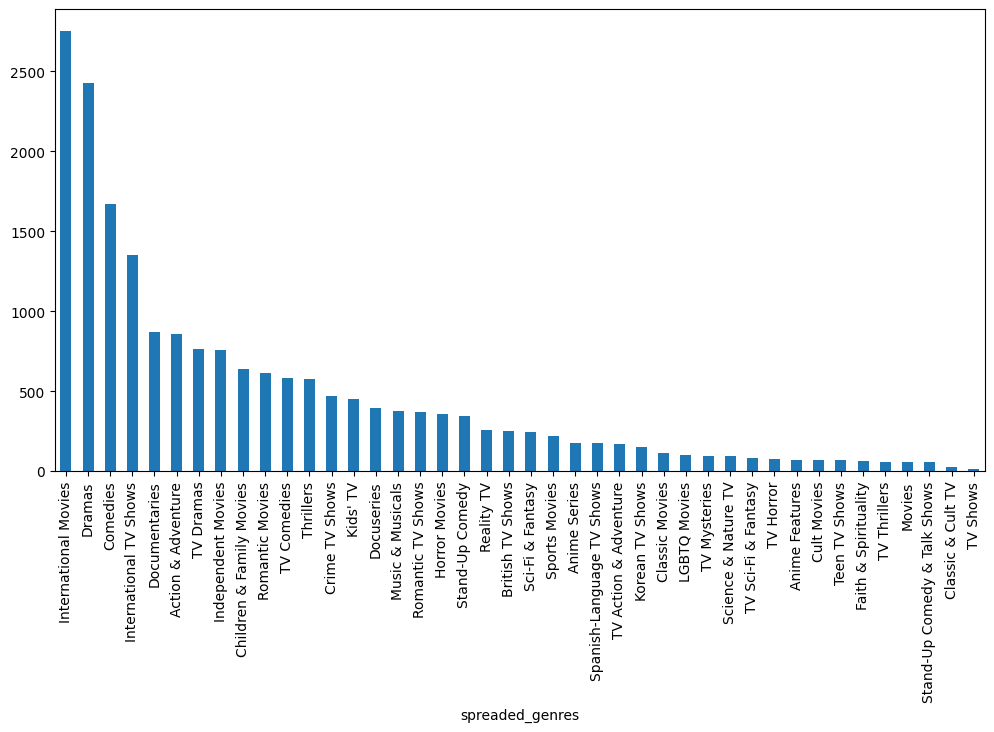

In [428]:
generes_exploded['spreaded_genres'].value_counts().plot(kind='bar', figsize=(12, 6))
plt.show()

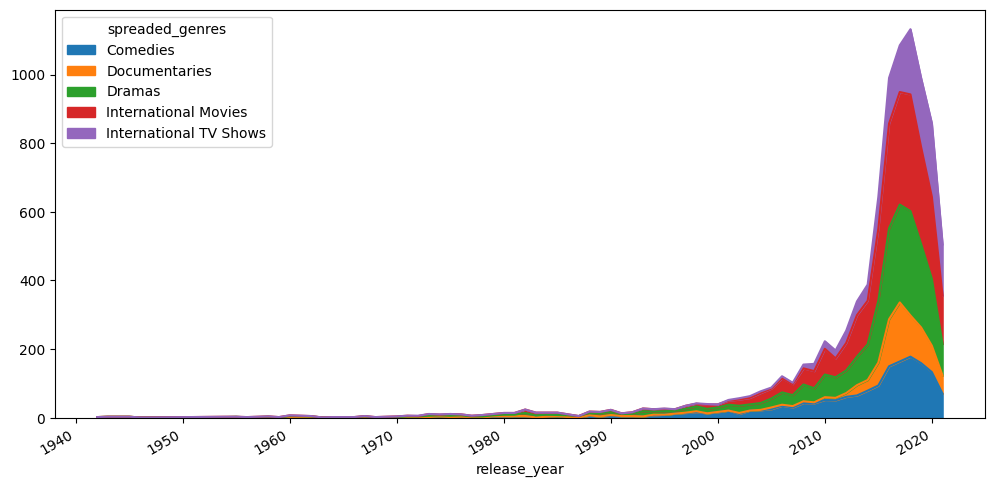

In [ ]:
top_five_genres = generes_exploded['spreaded_genres'].value_counts().head(5).index.tolist()

genres_per_year = generes_exploded[generes_exploded['spreaded_genres'].isin(top_five_genres)].groupby(['release_year', 'spreaded_genres']).size().unstack(fill_value=0)
genres_per_year.plot(kind='area', figsize=(12, 6))
plt.show()